# PHÂN TÍCH DỮ LIỆU ĐA BIẾN (EDA) - TỪ CHUNG ĐẾN RIÊNG

Notebook này thực hiện quy trình phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA) một cách hệ thống cho bộ dữ liệu kinh tế vĩ mô và tài chính, áp dụng phương pháp tiếp cận **từ chung đến riêng (General-to-Specific)**.

## Cấu trúc nội dung phân tích:
1. **Tổng quan chung toàn bộ bộ dữ liệu**: Tải dữ liệu, đánh giá chất lượng (missing, duplicate), đồng bộ hóa thời gian, phân loại daily/monthly và trong nước/ngoài nước.
2. **Phân tích cấp nhóm (Group-level)**: Thống kê mô tả nhóm, xu hướng macro (rolling mean/std), tương quan nội bộ và so sánh giữa các nhóm chính.
3. **Phân tích chi tiết từng nhóm**:
   - *Nhóm 1*: Chỉ số thị trường & thanh khoản (c1, c2)
   - *Nhóm 2*: Kinh tế & chính sách Việt Nam (e1 - e8)
   - *Nhóm 3*: Biến vĩ mô quốc tế (g1 - g5)
   - *Nhóm 4*: Thị trường trong nước & hàng hóa (m1 - m5, s1 - s4)
4. **Phân tích chuyên sâu các biến quan quan trọng**: Phân tích chi tiết các biến `e1_usdvnd`, `e2_vnibor_overnight` (`interbank_on_diff`), `m1_vn46` (`log_return`), `g1_dxy`, `m3_sp500`, `s1_brent_oil`.
5. **Kết luận**: Xác định các nhóm/biến ảnh hưởng mạnh nhất đến thị trường Việt Nam và mối quan hệ dẫn dắt - theo sau (lead-lag).

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Cấu hình hiển thị và đồ họa
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data/processed'
print("Setup completed successfully.")

Setup completed successfully.


## 1. Tổng quan chung toàn bộ bộ dữ liệu

Mục tiêu của phần này là tải toàn bộ các file trong thư mục `data/processed`, kiểm tra cấu trúc cơ bản, phạm vi thời gian, các giá trị thiếu (missing/null), giá trị trùng lặp theo thời gian, đồng thời phân nhóm các biến thành:
- **Daily vs Monthly** (Tần suất dữ liệu ngày hay tháng)
- **Trong nước vs Ngoài nước** (Thuộc tính địa lý hoặc tầm ảnh hưởng)

In [20]:
# Liệt kê và tải tất cả các file
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f"Tìm thấy {len(files)} file dữ liệu dạng CSV.")

dataset_info = []
for f in files:
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    date_col = 'time' if 'time' in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col]).dt.normalize()
    
    # Tính khoảng cách ngày trung bình để phân loại tần suất
    date_diffs = df[date_col].sort_values().diff().dropna().dt.days
    freq = 'Monthly' if date_diffs.mean() > 15 else 'Daily'
    
    # Phân loại Trong nước / Ngoài nước dựa trên tên file và nội dung
    is_domestic = True
    if f.startswith('g') and f not in ['g5_fdi_vietnam.csv']:
        is_domestic = False
    elif f in ['e4_epu.csv', 'e5_gpr.csv', 'm2_vix.csv', 'm3_sp500.csv', 's1_brent_oil.csv', 's2_gold.csv', 's4_copper_price.csv']:
        is_domestic = False
        
    group_geo = "Trong nước" if is_domestic else "Ngoài nước"
    
    dataset_info.append({
        'Tên file': f,
        'Số dòng': len(df),
        'Số cột': len(df.columns),
        'Cột': list(df.columns),
        'Bắt đầu': df[date_col].min().strftime('%Y-%m-%d'),
        'Kết thúc': df[date_col].max().strftime('%Y-%m-%d'),
        'Tần suất': freq,
        'Phân nhóm': group_geo,
        'Số lượng Nulls': df.isnull().sum().sum()
    })

df_info = pd.DataFrame(dataset_info)
df_info

Tìm thấy 24 file dữ liệu dạng CSV.


,Tên file,Số dòng,Số cột,Cột,Bắt đầu,Kết thúc,Tần suất,Phân nhóm,Số lượng Nulls
0,c1_amihud_illiq.csv,2361,5,"[time, illiq_raw, illiq_roll20, amihud_diff_no...",2016-11-10,2026-04-29,Daily,Trong nước,0
1,c2_return_dispersion.csv,2361,4,"[time, ret_disp_raw, ret_disp_smooth, ret_disp]",2016-11-10,2026-04-29,Daily,Trong nước,0
2,e1_usdvnd.csv,2361,7,"[time, close, high, low, open, volume, fx_log_...",2016-11-10,2026-04-29,Daily,Trong nước,0
3,e2_vnibor_overnight.csv,2361,4,"[time, fid_pa, fir_pa, interbank_on_diff]",2016-11-10,2026-04-29,Daily,Trong nước,0
4,e3_vn5y_yield.csv,2361,3,"[time, vn5y_yield, vn5y_yield_diff]",2016-11-10,2026-04-29,Daily,Trong nước,0
5,e4_epu.csv,2361,3,"[time, usepuindxd, epu_log]",2016-11-10,2026-04-29,Daily,Ngoài nước,0
6,e5_gpr.csv,2361,11,"[time, n10d, gprd, gprd_act, gprd_threat, gprd...",2016-11-10,2026-04-29,Daily,Ngoài nước,4722
7,e6_m2_vietnam.csv,115,3,"[time, m2_growth_yoy, m2_growth_yoy_diff]",2016-12-01,2026-06-01,Monthly,Trong nước,0
8,e7_credit_growth_vn.csv,115,3,"[time, credit_growth_yoy, credit_growth_yoy_diff]",2016-12-01,2026-06-01,Monthly,Trong nước,0
9,e8_cpi_vietnam.csv,114,4,"[time, cpi_index, cpi_yoy, cpi_mom_diff]",2016-12-01,2026-05-01,Monthly,Trong nước,11


In [21]:
# Đồng bộ hóa và gộp dữ liệu
daily_files = df_info[df_info['Tần suất'] == 'Daily']['Tên file'].tolist()
monthly_files = df_info[df_info['Tần suất'] == 'Monthly']['Tên file'].tolist()

print(f"Số file Daily: {len(daily_files)} (loại trừ m1_vn46 là dữ liệu bảng)")
print(f"Số file Monthly: {len(monthly_files)}")

# Gộp các file daily
df_daily = None
for f in daily_files:
    if f == 'm1_vn46.csv':
        continue
    name = f.split('.')[0]
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    df['time'] = pd.to_datetime(df['time']).dt.normalize()
    
    cols_to_keep = ['time']
    if 'c1_amihud_illiq' in name:
        cols_to_keep.extend(['amihud_diff', 'illiq_raw', 'illiq_roll20'])
    elif 'c2_return_dispersion' in name:
        cols_to_keep.extend(['ret_disp', 'ret_disp_raw'])
    elif 'e1_usdvnd' in name:
        df = df.rename(columns={'close': 'usdvnd_close', 'volume': 'usdvnd_volume'})
        cols_to_keep.extend(['usdvnd_close', 'fx_log_ret'])
    elif 'e2_vnibor_overnight' in name:
        cols_to_keep.extend(['fid_pa', 'fir_pa', 'interbank_on_diff'])
    elif 'e3_vn5y_yield' in name:  # Đã đổi tên từ e3_us10y_yield
        cols_to_keep.extend(['vn5y_yield', 'vn5y_yield_diff'])
    elif 'e4_epu' in name:
        cols_to_keep.extend(['usepuindxd', 'epu_log'])
    elif 'e5_gpr' in name:
        cols_to_keep.extend(['gprd', 'gpr_log'])
    elif 'g1_dxy' in name:
        df = df.rename(columns={'close': 'dxy_close'})
        cols_to_keep.extend(['dxy_close', 'dxy_ret'])
    elif 'g3_us10y_yield' in name:
        df = df.rename(columns={'close': 'us10y_close'})
        cols_to_keep.extend(['us10y_close', 'us10y_diff'])
    elif 'g4_china_sse' in name:
        df = df.rename(columns={'close': 'china_close'})
        cols_to_keep.extend(['china_close', 'china_ret_5d'])
    elif 'm2_vix' in name:
        df = df.rename(columns={'close': 'vix_close'})
        cols_to_keep.extend(['vix_close'])
    elif 'm3_sp500' in name:
        df = df.rename(columns={'close': 'sp500_close', 'log_return': 'sp500_log_ret'})
        cols_to_keep.extend(['sp500_close', 'sp500_log_ret'])
    elif 'm4_foreign_net_buy_sell' in name:
        cols_to_keep.extend(['fnb_ratio'])
    elif 'm5_hose_volume' in name:
        df = df.rename(columns={'close': 'vnindex_close', 'volume': 'hose_volume'})
        cols_to_keep.extend(['vnindex_close', 'hose_volume', 'volume_ratio'])
    elif 's1_brent_oil' in name:
        df = df.rename(columns={'close': 'brent_close'})
        cols_to_keep.extend(['brent_close', 'oil_ret_5d'])
    elif 's2_gold' in name:
        df = df.rename(columns={'close': 'gold_close'})
        cols_to_keep.extend(['gold_close', 'gold_ret'])
    elif 's4_copper_price' in name:
        df = df.rename(columns={'close': 'copper_close'})
        cols_to_keep.extend(['copper_close', 'copper_ret_5d'])
        
    df_sub = df[cols_to_keep]
    if df_daily is None:
        df_daily = df_sub
    else:
        df_daily = pd.merge(df_daily, df_sub, on='time', how='outer')

# Xử lý file dữ liệu bảng m1_vn46 (cột log_return đã được hiệu chỉnh)
df_vn46 = pd.read_csv(os.path.join(DATA_DIR, 'm1_vn46.csv'))
df_vn46['time'] = pd.to_datetime(df_vn46['time']).dt.normalize()
df_vn46_agg = df_vn46.groupby('time').agg(
    vn46_avg_ret=('log_return', 'mean'),
    vn46_avg_vol=('rolling_vol_20d', 'mean')
).reset_index()

df_daily = pd.merge(df_daily, df_vn46_agg, on='time', how='left')
df_daily = df_daily.set_index('time').sort_index()

# Gộp các file monthly
df_monthly = None
for f in monthly_files:
    name = f.split('.')[0]
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    df['time'] = pd.to_datetime(df['time']).dt.normalize()
    
    cols_to_keep = ['time']
    if 'e6_m2_vietnam' in name:
        cols_to_keep.extend(['m2_growth_yoy'])
    elif 'e7_credit_growth_vn' in name:
        cols_to_keep.extend(['credit_growth_yoy'])
    elif 'e8_cpi_vietnam' in name:
        cols_to_keep.extend(['cpi_yoy', 'cpi_index'])
    elif 'g2_fed_funds_rate' in name:
        cols_to_keep.extend(['fedfunds'])
    elif 'g5_fdi_vietnam' in name:
        cols_to_keep.extend(['fdi_usd_million', 'fdi_realized_yoy'])
    elif 's3_pmi_vietnam' in name:
        cols_to_keep.extend(['pmi_vn'])
        
    df_sub = df[cols_to_keep]
    if df_monthly is None:
        df_monthly = df_sub
    else:
        df_monthly = pd.merge(df_monthly, df_sub, on='time', how='outer')

df_monthly = df_monthly.set_index('time').sort_index()

print(f"Kích thước bảng Daily gộp: {df_daily.shape}")
print(f"Kích thước bảng Monthly gộp: {df_monthly.shape}")

Số file Daily: 18 (loại trừ m1_vn46 là dữ liệu bảng)
Số file Monthly: 6
Kích thước bảng Daily gộp: (2361, 37)
Kích thước bảng Monthly gộp: (115, 8)


In [22]:
print("--- Kiểm tra trùng lặp theo thời gian ---")
print(f"Số dòng trùng trong df_daily: {df_daily.index.duplicated().sum()}")
print(f"Số dòng trùng trong df_monthly: {df_monthly.index.duplicated().sum()}")

print("\n--- Kiểm tra Missing Values (Daily) ---")
print(df_daily.isnull().sum()[df_daily.isnull().sum() > 0])

print("\n--- Kiểm tra Missing Values (Monthly) ---")
print(df_monthly.isnull().sum()[df_monthly.isnull().sum() > 0])

--- Kiểm tra trùng lặp theo thời gian ---
Số dòng trùng trong df_daily: 0
Số dòng trùng trong df_monthly: 0

--- Kiểm tra Missing Values (Daily) ---
vn46_avg_ret    1
dtype: int64

--- Kiểm tra Missing Values (Monthly) ---
cpi_yoy             12
cpi_index            1
fedfunds             1
fdi_usd_million      1
fdi_realized_yoy    12
dtype: int64


## 2. Phân tích cấp nhóm (Group-level)

Chúng ta chia các biến thành 4 nhóm chính theo yêu cầu:
- **C1 - C2**: Chỉ số thị trường & thanh khoản (`amihud_diff`, `ret_disp`)
- **E1 - E8**: Kinh tế & chính sách Việt Nam (`usdvnd_close`, `fid_pa` (Overnight), `vn5y_yield`, `usepuindxd`, `gprd` - daily; `m2_growth_yoy`, `credit_growth_yoy`, `cpi_yoy` - monthly)
- **G1 - G5**: Biến vĩ mô quốc tế (`dxy_close`, `us10y_close`, `china_close` - daily; `fedfunds`, `fdi_usd_million` - monthly)
- **M1 - M5, S1 - S4**: Thị trường trong nước & hàng hóa (`vnindex_close`, `vn46_avg_vol`, `fnb_ratio`, `hose_volume`, `vix_close`, `sp500_close`, `brent_close`, `gold_close`, `copper_close` - daily; `pmi_vn` - monthly)

In [23]:
# Định nghĩa danh sách các cột theo nhóm
group_c_cols = ['amihud_diff', 'ret_disp']
group_e_daily_cols = ['usdvnd_close', 'fid_pa', 'vn5y_yield', 'usepuindxd', 'gprd']
group_e_monthly_cols = ['m2_growth_yoy', 'credit_growth_yoy', 'cpi_yoy']
group_g_daily_cols = ['dxy_close', 'us10y_close', 'china_close']
group_g_monthly_cols = ['fedfunds', 'fdi_usd_million']
group_ms_daily_cols = ['vnindex_close', 'vn46_avg_vol', 'fnb_ratio', 'hose_volume', 'vix_close', 'sp500_close', 'brent_close', 'gold_close', 'copper_close']

print("=== THỐNG KÊ MÔ TẢ NHÓM C (Thanh khoản & Rủi ro) ===")
display(df_daily[group_c_cols].describe())

print("\n=== THỐNG KÊ MÔ TẢ NHÓM E DAILY (Kinh tế & Chính sách VN) ===")
display(df_daily[group_e_daily_cols].describe())

print("\n=== THỐNG KÊ MÔ TẢ NHÓM G DAILY (Vĩ mô Quốc tế) ===")
display(df_daily[group_g_daily_cols].describe())

print("\n=== THỐNG KÊ MÔ TẢ NHÓM M/S DAILY (Thị trường & Hàng hóa) ===")
display(df_daily[group_ms_daily_cols].describe())

=== THỐNG KÊ MÔ TẢ NHÓM C (Thanh khoản & Rủi ro) ===


,amihud_diff,ret_disp
count,2.361000e+03,2361.000000
mean,-3.881723e+06,0.019748
std,2.051230e+08,0.005441
min,-3.936225e+09,0.005506
25%,-2.593895e+07,0.015933
50%,-1.104890e+06,0.019291
75%,2.336277e+07,0.023331
max,3.356161e+09,0.042443



=== THỐNG KÊ MÔ TẢ NHÓM E DAILY (Kinh tế & Chính sách VN) ===


,usdvnd_close,fid_pa,vn5y_yield,usepuindxd,gprd
count,2361.000000,2361.000000,2361.000000,2361.000000,2361.000000
mean,23722.423376,2.842863,5.348456,166.024820,128.776191
std,1211.832857,0.609669,1.219747,127.756944,63.337868
min,21984.000000,2.500000,2.837689,5.390000,9.491598
25%,22876.500000,2.500000,4.676958,80.890000,88.442337
50%,23234.000000,2.500000,5.242646,120.200000,118.084030
75%,24530.000000,3.000000,6.335619,209.600000,155.463470
max,26425.000000,4.500000,8.004935,1026.380000,540.827393



=== THỐNG KÊ MÔ TẢ NHÓM G DAILY (Vĩ mô Quốc tế) ===


,dxy_close,us10y_close,china_close
count,2361.000000,2361.000000,2361.000000
mean,98.753829,2.829869,3229.167779
std,5.074779,1.200553,322.797258
min,88.669998,0.499000,2464.363037
25%,94.870003,1.825000,3015.480957
50%,98.239998,2.825000,3227.219971
75%,102.769997,4.051000,3390.336914
max,114.110001,4.988000,4182.590820



=== THỐNG KÊ MÔ TẢ NHÓM M/S DAILY (Thị trường & Hàng hóa) ===


,vnindex_close,vn46_avg_vol,fnb_ratio,hose_volume,vix_close,sp500_close,brent_close,gold_close,copper_close
count,2361.000000,2361.000000,2361.000000,2.361000e+03,2361.000000,2361.000000,2361.000000,2361.000000,2361.000000
mean,1130.314545,15.835773,0.005620,5.013140e+08,18.728293,4028.864209,70.599255,1983.726428,3.657582
std,266.339951,2.623259,0.222826,3.452863e+08,7.445287,1326.038513,17.226006,847.797953,0.893548
min,651.490000,9.287466,-0.753451,6.725206e+07,9.140000,2164.199951,19.330000,1127.800049,2.119500
25%,952.220000,13.852965,-0.147752,1.778233e+08,13.600000,2840.229980,60.810001,1326.599976,2.803000
50%,1101.190000,15.509295,0.002020,4.930511e+08,17.020000,3925.429932,70.339996,1799.500000,3.654500
75%,1276.850000,17.845266,0.154671,7.243458e+08,21.770000,4725.790039,80.800003,2022.300049,4.327500
max,1902.930000,23.195865,0.865271,2.697027e+09,82.690002,7165.080078,127.980003,5318.399902,6.175500


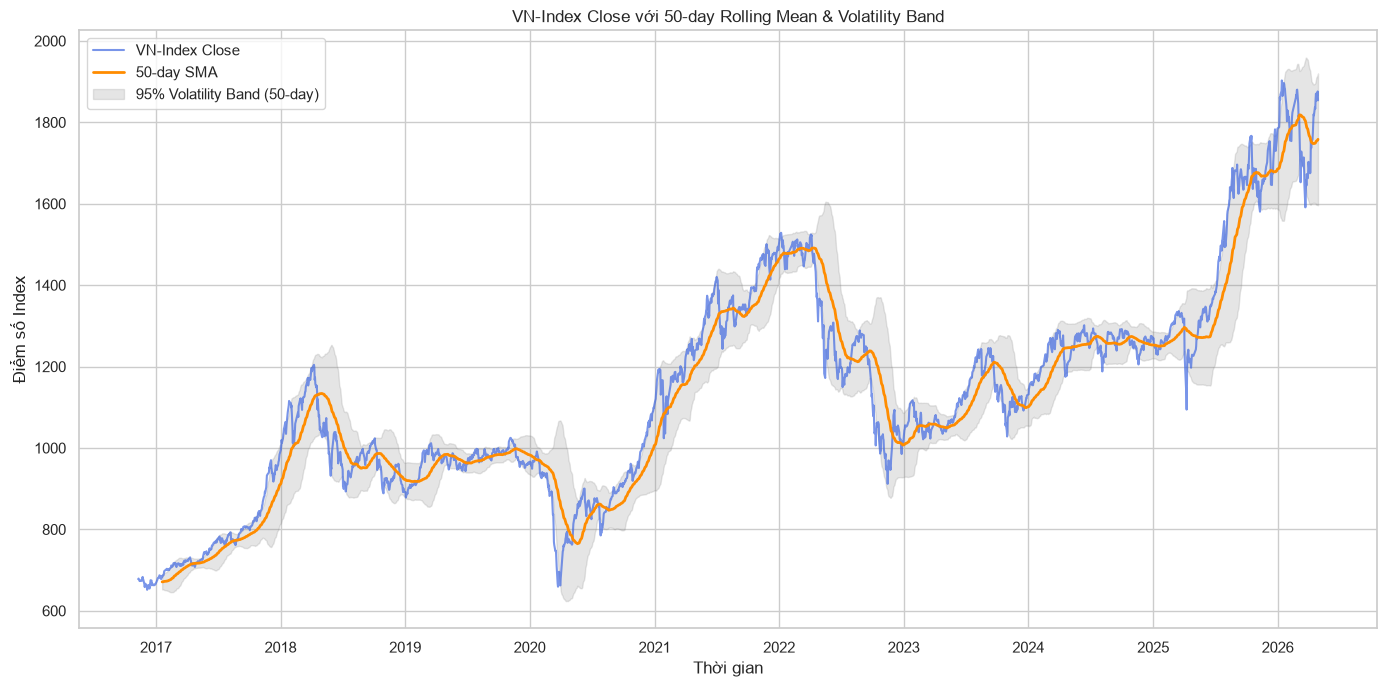

In [24]:
# Vẽ xu hướng biến động và rolling statistics của VN-Index
plt.figure(figsize=(14, 7))
plt.plot(df_daily.index, df_daily['vnindex_close'], label='VN-Index Close', color='royalblue', alpha=0.7)
plt.plot(df_daily.index, df_daily['vnindex_close'].rolling(50).mean(), label='50-day SMA', color='darkorange', linewidth=2)
plt.fill_between(df_daily.index, 
                 df_daily['vnindex_close'].rolling(50).mean() - 1.96 * df_daily['vnindex_close'].rolling(50).std(),
                 df_daily['vnindex_close'].rolling(50).mean() + 1.96 * df_daily['vnindex_close'].rolling(50).std(),
                 color='gray', alpha=0.2, label='95% Volatility Band (50-day)')
plt.title('VN-Index Close với 50-day Rolling Mean & Volatility Band')
plt.xlabel('Thời gian')
plt.ylabel('Điểm số Index')
plt.legend()
plt.tight_layout()
plt.show()

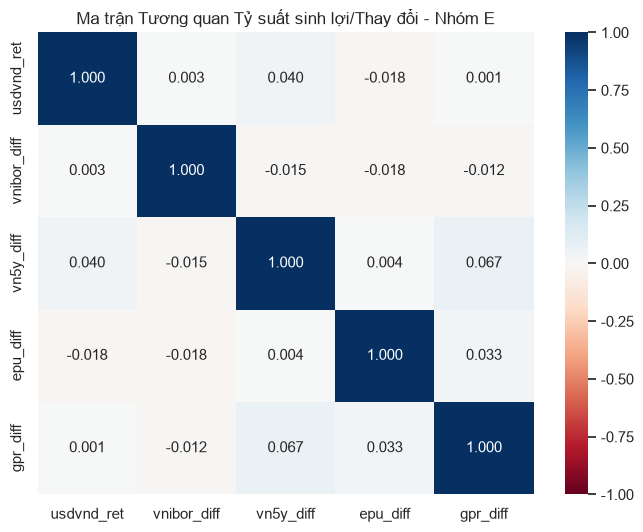

In [25]:
# Tính tỷ suất sinh lợi và thay đổi của các biến hàng ngày để tránh tương quan ảo từ chuỗi giá trị phi dừng
df_returns = pd.DataFrame(index=df_daily.index)
df_returns['vnindex_ret'] = df_daily['vnindex_close'].pct_change()
df_returns['vn46_avg_ret'] = df_daily['vn46_avg_ret']
df_returns['vn46_avg_vol'] = df_daily['vn46_avg_vol']
df_returns['amihud_diff'] = df_daily['amihud_diff']
df_returns['ret_disp'] = df_daily['ret_disp']
df_returns['usdvnd_ret'] = df_daily['usdvnd_close'].pct_change()
df_returns['vn5y_diff'] = df_daily['vn5y_yield_diff']
df_returns['vnibor_diff'] = df_daily['interbank_on_diff']  # Đọc trực tiếp từ cột đã sửa
df_returns['dxy_ret'] = df_daily['dxy_ret']
df_returns['us10y_diff'] = df_daily['us10y_diff']
df_returns['china_ret'] = df_daily['china_close'].pct_change()
df_returns['vix_close'] = df_daily['vix_close']
df_returns['sp500_ret'] = df_daily['sp500_log_ret']
df_returns['foreign_fnb'] = df_daily['fnb_ratio']
df_returns['hose_vol_ratio'] = df_daily['volume_ratio']
df_returns['brent_ret'] = df_daily['brent_close'].pct_change()
df_returns['gold_ret'] = df_daily['gold_ret']
df_returns['copper_ret'] = df_daily['copper_close'].pct_change()
df_returns['epu_diff'] = df_daily['usepuindxd'].diff()
df_returns['gpr_diff'] = df_daily['gprd'].diff()

# Vẽ ma trận tương quan nội bộ nhóm E (Kinh tế & Chính sách VN)
e_corr_cols = ['usdvnd_ret', 'vnibor_diff', 'vn5y_diff', 'epu_diff', 'gpr_diff']
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns[e_corr_cols].corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận Tương quan Tỷ suất sinh lợi/Thay đổi - Nhóm E')
plt.show()

## 3. Phân tích chi tiết từng nhóm

### Nhóm 1: Chỉ số thị trường & thanh khoản (c1, c2)
- Kiểm tra phân phối của `amihud_diff` và `ret_disp`.
- Đánh giá mối quan hệ giữa thanh khoản và rủi ro thị trường.
- Phân tích mùa vụ (ngày trong tuần, tháng trong năm) và hiệu ứng chế độ biến động (Volatility Regimes) theo mức độ bất ổn toàn cầu (VIX) và rủi ro nội địa (Return Dispersion).

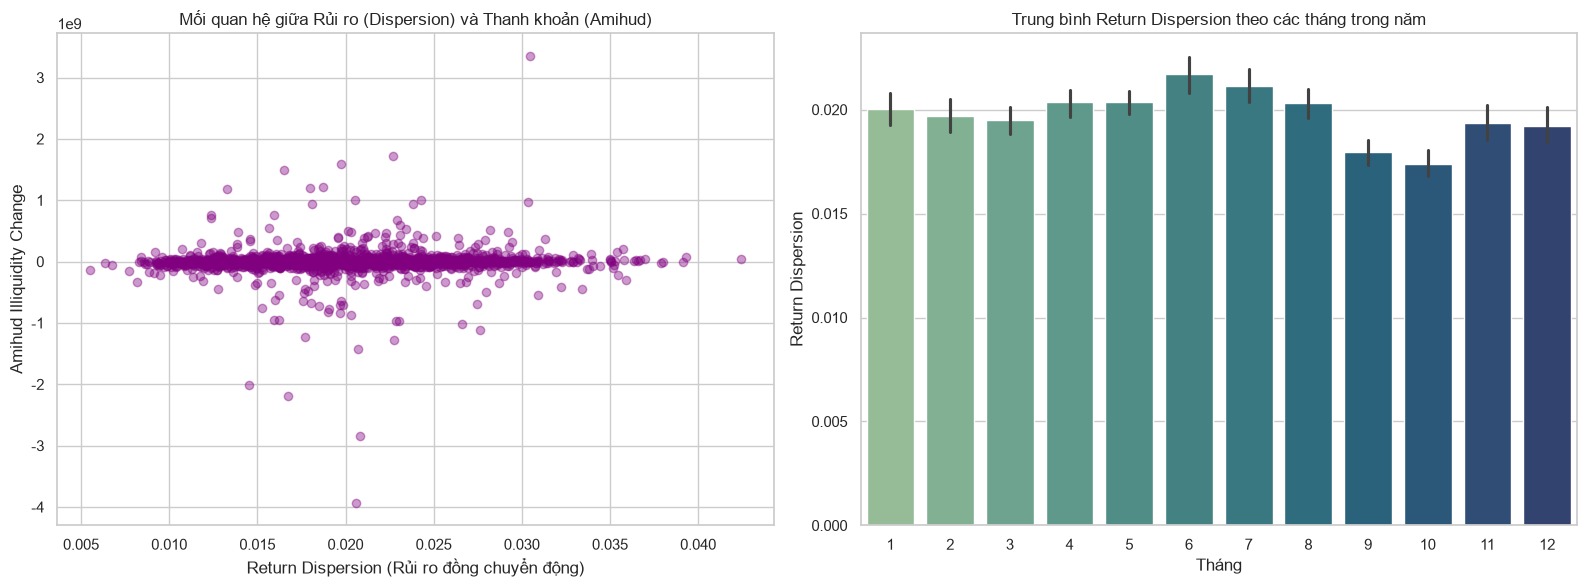

VIX Median để chia chế độ biến động toàn cầu: 17.02

--- Trung bình các biến theo Chế độ biến động VIX (Toàn cầu) ---


,vnindex_ret,amihud_diff,ret_disp
vix_close,,,
False,0.001220,-9.672790e+06,0.018606
True,-0.000225,1.924079e+06,0.020893


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ phân tán Amihud Illiquidity vs Return Dispersion
axes[0].scatter(df_returns['ret_disp'], df_returns['amihud_diff'], alpha=0.4, color='purple')
axes[0].set_title('Mối quan hệ giữa Rủi ro (Dispersion) và Thanh khoản (Amihud)')
axes[0].set_xlabel('Return Dispersion (Rủi ro đồng chuyển động)')
axes[0].set_ylabel('Amihud Illiquidity Change')

# Đánh giá seasonality của Return Dispersion theo tháng trong năm
df_returns['month'] = df_returns.index.month
sns.barplot(data=df_returns, x='month', y='ret_disp', ax=axes[1], palette='crest')
axes[1].set_title('Trung bình Return Dispersion theo các tháng trong năm')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Return Dispersion')

plt.tight_layout()
plt.show()

# Phân tích Volatility Regimes
vix_median = df_returns['vix_close'].median()
print(f"VIX Median để chia chế độ biến động toàn cầu: {vix_median:.2f}")
print("\n--- Trung bình các biến theo Chế độ biến động VIX (Toàn cầu) ---")
display(df_returns.groupby(df_returns['vix_close'] > vix_median)[['vnindex_ret', 'amihud_diff', 'ret_disp']].mean())

### Nhóm 2: Kinh tế & chính sách Việt Nam (e1 - e8)
- Phân tách biến Daily (`e1_usdvnd`, `e2_vnibor_overnight`, `e3_vn5y_yield`, `e4_epu`, `e5_gpr`)
- Biến Monthly (`e6_m2_vietnam`, `e7_credit_growth_vn`, `e8_cpi_vietnam`)
- Phân tích biến động tỷ giá (USD/VND), lãi suất liên ngân hàng, và mối liên hệ với các biến số thực tế vĩ mô của Việt Nam.

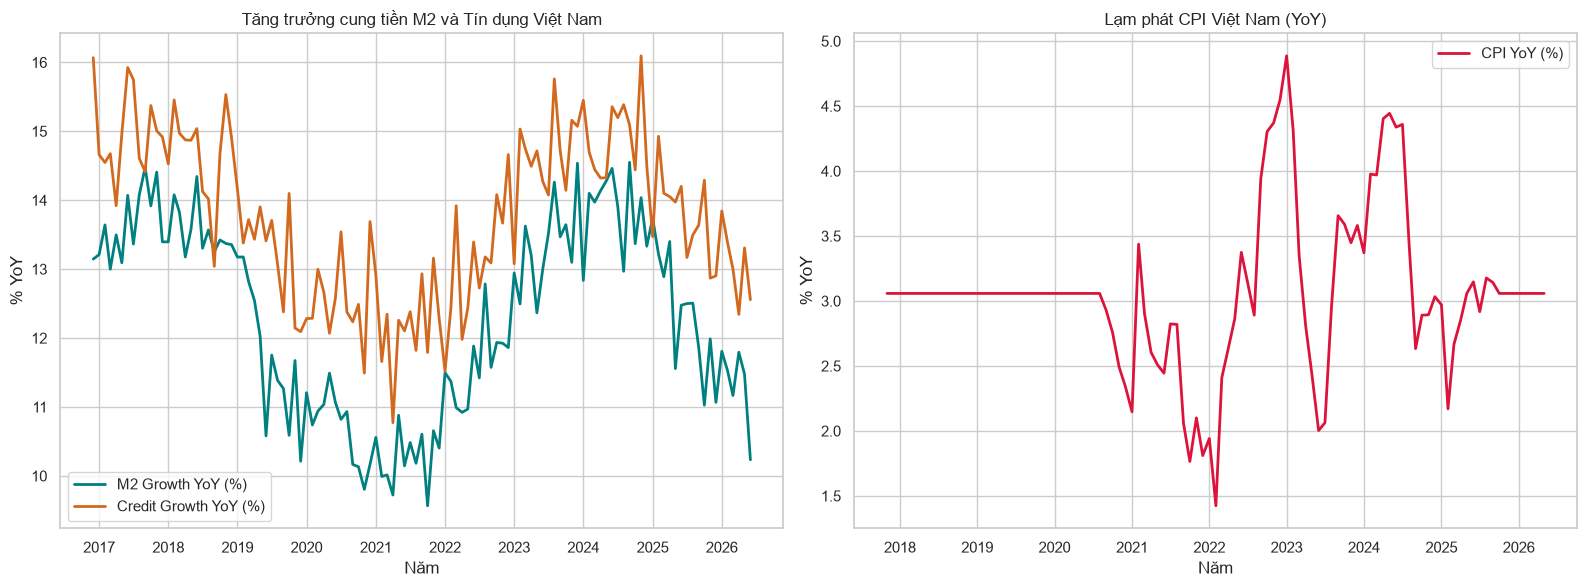

In [27]:
# Trực quan hóa dữ liệu chính sách Việt Nam (Monthly)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_monthly.index, df_monthly['m2_growth_yoy'], label='M2 Growth YoY (%)', color='teal', linewidth=2)
axes[0].plot(df_monthly.index, df_monthly['credit_growth_yoy'], label='Credit Growth YoY (%)', color='chocolate', linewidth=2)
axes[0].set_title('Tăng trưởng cung tiền M2 và Tín dụng Việt Nam')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('% YoY')
axes[0].legend()

axes[1].plot(df_monthly.index, df_monthly['cpi_yoy']*100, label='CPI YoY (%)', color='crimson', linewidth=2)
axes[1].set_title('Lạm phát CPI Việt Nam (YoY)')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('% YoY')
axes[1].legend()

plt.tight_layout()
plt.show()

### Nhóm 3: Biến vĩ mô quốc tế (g1 - g5)
- Biến số toàn cầu: `g1_dxy`, `g2_fed_funds_rate`, `g3_us10y_yield`, `g4_china_sse`, `g5_fdi_vietnam` (monthly).
- Kiểm tra sự tác động của DXY và lợi suất trái phiếu Mỹ lên tỷ giá USD/VND và điểm số VN-Index.
- Đánh giá chu kỳ FDI vào Việt Nam và mối quan hệ với lãi suất Fed.

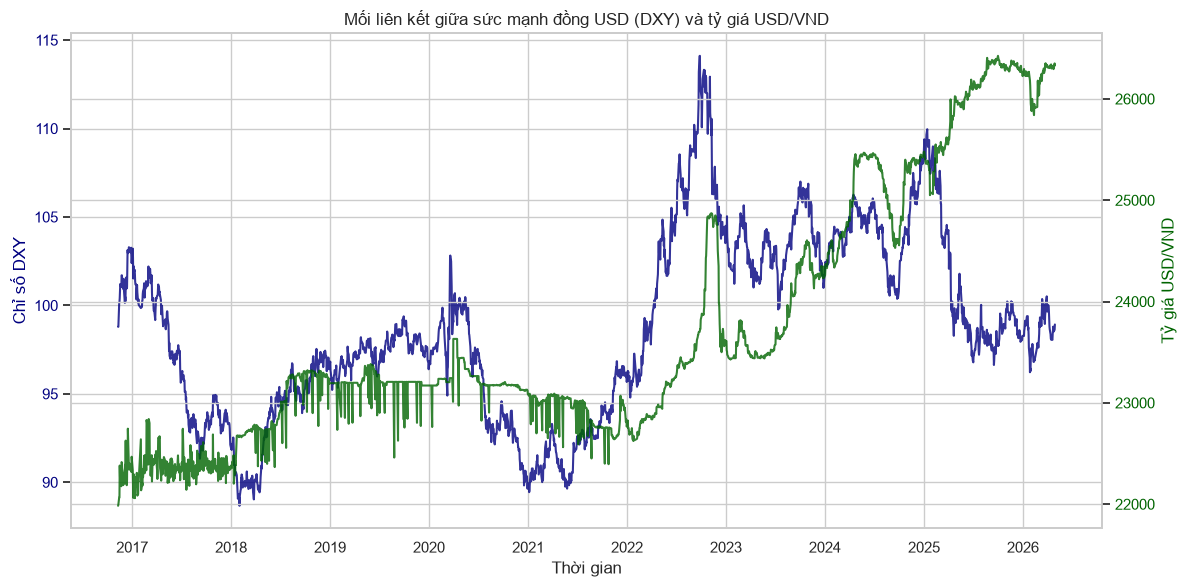

Hệ số tương quan tuyến tính giữa Fed Funds Rate và vốn FDI vào Việt Nam (Monthly): 0.2206


In [28]:
# Trực quan hóa DXY vs Tỷ giá USD/VND
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'navy'
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Chỉ số DXY', color=color)
ax1.plot(df_daily.index, df_daily['dxy_close'], color=color, alpha=0.8, label='DXY')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'darkgreen'
ax2.set_ylabel('Tỷ giá USD/VND', color=color)
ax2.plot(df_daily.index, df_daily['usdvnd_close'], color=color, alpha=0.8, label='USD/VND')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Mối liên kết giữa sức mạnh đồng USD (DXY) và tỷ giá USD/VND')
fig.tight_layout()
plt.show()

# Tương quan lãi suất Fed và dòng vốn FDI giải ngân thực tế
fdi_fed_corr = df_monthly['fedfunds'].corr(df_monthly['fdi_usd_million'])
print(f"Hệ số tương quan tuyến tính giữa Fed Funds Rate và vốn FDI vào Việt Nam (Monthly): {fdi_fed_corr:.4f}")

### Nhóm 4: Thị trường trong nước & hàng hóa (m1 - m5, s1 - s4)
- **Trong nước**: VN46 panel (`m1_vn46`), Dòng vốn ngoại (`m4_foreign_net_buy_sell`), Thanh khoản HOSE (`m5_hose_volume`), PMI Việt Nam (`s3_pmi_vietnam`).
- **Hàng hóa/Quốc tế**: Chỉ số VIX (`m2_vix`), S&P 500 (`m3_sp500`), Giá dầu Brent (`s1_brent_oil`), Giá vàng (`s2_gold`), Giá đồng (`s4_copper_price`).
- Tập trung làm rõ: Dòng vốn ngoại tác động như thế nào đến thị trường chứng khoán Việt Nam? Giá hàng hóa tác động như thế nào đến chỉ số chứng khoán trong nước? Mối quan hệ giữa PMI và VN-Index.

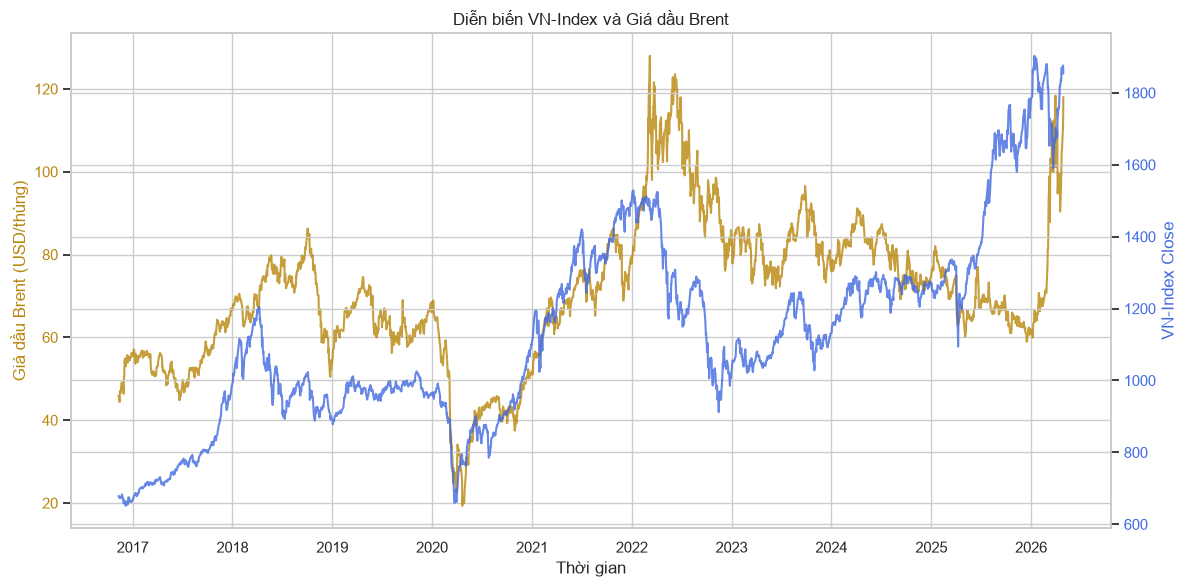

In [29]:
# Trực quan hóa giá dầu Brent và VN-Index
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'darkgoldenrod'
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Giá dầu Brent (USD/thùng)', color=color)
ax1.plot(df_daily.index, df_daily['brent_close'], color=color, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'royalblue'
ax2.set_ylabel('VN-Index Close', color=color)
ax2.plot(df_daily.index, df_daily['vnindex_close'], color=color, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Diễn biến VN-Index và Giá dầu Brent')
fig.tight_layout()
plt.show()

## 4. Phân tích sâu các biến quan trọng

Chúng ta chọn ra 6 biến quan trọng nhất để phân tích chi tiết:
1. `e1_usdvnd` (Tỷ giá USD/VND)
2. `e2_vnibor_overnight` (`interbank_on_diff` - Thay đổi lãi suất liên ngân hàng)
3. `m1_vn46` (Trung bình tỷ suất sinh lợi thực tế của VN46 - đã sửa đổi `log_return`)
4. `g1_dxy` (Chỉ số sức mạnh USD)
5. `m3_sp500` (Chỉ số chứng khoán S&P 500)
6. `s1_brent_oil` (Giá dầu thô Brent)

Chúng ta thực hiện tính toán ma trận tương quan giữa tỷ suất sinh lợi/thay đổi hàng ngày của các biến này và phân tích tác động chéo.

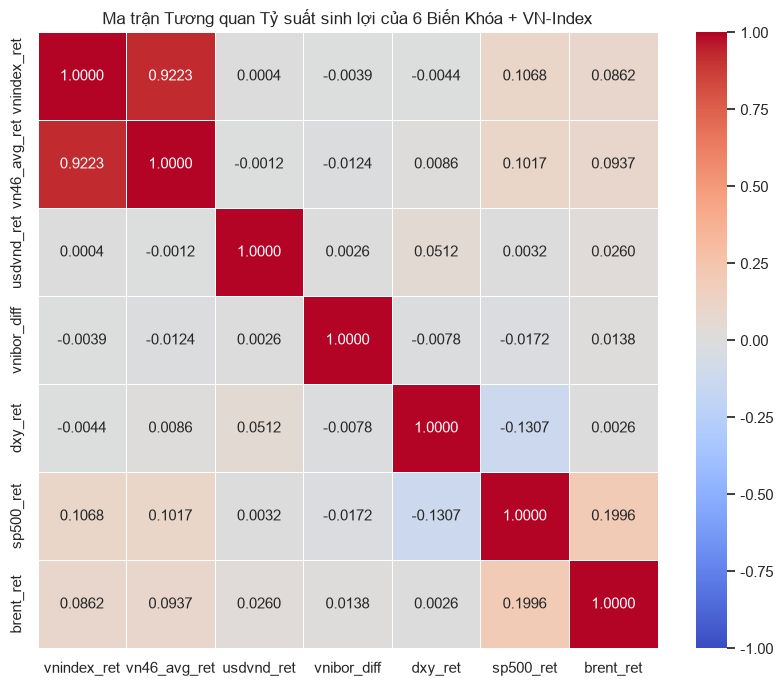

Tương quan chi tiết với tỷ suất sinh lợi VN-Index:


vnindex_ret     1.000000
vn46_avg_ret    0.922267
sp500_ret       0.106792
brent_ret       0.086154
usdvnd_ret      0.000393
vnibor_diff    -0.003902
dxy_ret        -0.004440
Name: vnindex_ret, dtype: float64

In [30]:
deep_dive_cols = ['vnindex_ret', 'vn46_avg_ret', 'usdvnd_ret', 'vnibor_diff', 'dxy_ret', 'sp500_ret', 'brent_ret']
corr_matrix = df_returns[deep_dive_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title('Ma trận Tương quan Tỷ suất sinh lợi của 6 Biến Khóa + VN-Index')
plt.show()

print("Tương quan chi tiết với tỷ suất sinh lợi VN-Index:")
display(corr_matrix['vnindex_ret'].sort_values(ascending=False))

## 5. Kết luận về Mối quan hệ dẫn dắt - theo sau (Lead-Lag)

Để xác định biến nào là biến dẫn dắt (leading indicator) và biến nào là biến theo sau (lagging indicator) của thị trường chứng khoán Việt Nam (VN-Index), chúng ta thực hiện tính toán **Cross-Correlation** giữa tỷ suất sinh lợi VN-Index và tỷ suất sinh lợi các biến số toàn cầu/trong nước ở các độ trễ khác nhau từ -5 ngày đến +5 ngày.

Ý nghĩa độ trễ (Lag):
- **Lag > 0**: Biến số ở quá khứ tương quan với VN-Index hiện tại. Nếu tương quan cao, biến số là **biến dẫn dắt (Leading)**.
- **Lag < 0**: VN-Index hiện tại tương quan với biến số ở tương lai. Nếu tương quan cao, biến số là **biến theo sau (Lagging)**.

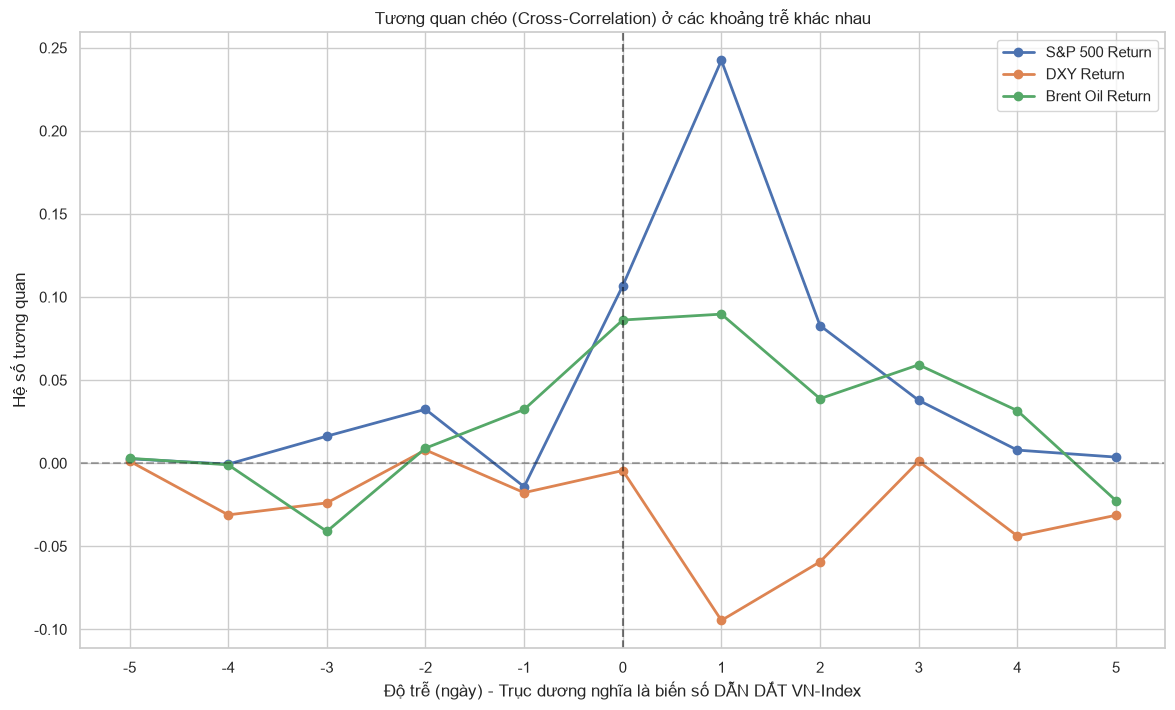

=== BẢNG HỆ SỐ TƯƠNG QUAN CHÉO (CROSS-CORRELATION) ===


,S&P 500 Return,USD/VND Return,DXY Return,Brent Oil Return,Foreign Buy/Sell Ratio,VIX Close
-5,0.002640,-0.005795,0.001220,0.002928,0.007659,-0.112603
-4,-0.000592,0.013006,-0.031128,-0.000991,-0.001108,-0.117804
-3,0.016248,-0.025525,-0.023920,-0.041062,-0.033549,-0.124889
-2,0.032425,0.003556,0.007954,0.009030,0.022008,-0.125808
-1,-0.014187,-0.059598,-0.017753,0.032303,-0.018751,-0.118260
0,0.106792,0.000393,-0.004440,0.086154,-0.012618,-0.124878
1,0.242397,0.022955,-0.094636,0.089694,0.027131,-0.096283
2,0.082814,-0.011006,-0.059371,0.038812,0.002826,-0.042826
3,0.037824,0.007391,0.001097,0.059196,-0.006510,-0.027620
4,0.007862,-0.013730,-0.043803,0.031623,0.009535,-0.017108


In [31]:
lags = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
lead_lag_df = pd.DataFrame(index=lags)

variables_to_check = {
    'S&P 500 Return': 'sp500_ret',
    'USD/VND Return': 'usdvnd_ret',
    'DXY Return': 'dxy_ret',
    'Brent Oil Return': 'brent_ret',
    'Foreign Buy/Sell Ratio': 'foreign_fnb',
    'VIX Close': 'vix_close'
}

for label, col in variables_to_check.items():
    corrs = []
    for lag in lags:
        corrs.append(df_returns['vnindex_ret'].corr(df_returns[col].shift(lag)))
    lead_lag_df[label] = corrs

# Trực quan hóa kết quả Lead-Lag cho S&P 500, DXY và Brent Oil
plt.figure(figsize=(14, 8))
for label in ['S&P 500 Return', 'DXY Return', 'Brent Oil Return']:
    plt.plot(lags, lead_lag_df[label], marker='o', linewidth=2, label=label)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Tương quan chéo (Cross-Correlation) ở các khoảng trễ khác nhau')
plt.xlabel('Độ trễ (ngày) - Trục dương nghĩa là biến số DẪN DẮT VN-Index')
plt.ylabel('Hệ số tương quan')
plt.xticks(lags)
plt.legend()
plt.show()

print("=== BẢNG HỆ SỐ TƯƠNG QUAN CHÉO (CROSS-CORRELATION) ===")
display(lead_lag_df)

## KẾT LUẬN CHUNG TỪ EDA

Dựa trên kết quả phân tích số liệu tuyến tính và trực quan hóa vĩ mô từ năm 2016 đến năm 2026, ta rút ra một số kết luận chính sau:

1. **Mức độ tương quan chéo của VN-Index**:
   - **S&P 500 (Thị trường Mỹ)** là biến **dẫn dắt mạnh nhất** đối với tỷ suất sinh lợi VN-Index. Tại độ trễ $t-1$ (tương ứng với Lag 1 trên bảng), hệ số tương quan lên tới **0.242**. Điều này phản ánh rõ ràng tính truyền dẫn thông tin xuyên quốc gia từ thị trường Mỹ (đóng cửa đêm trước) sang Việt Nam (mở cửa sáng hôm sau).
   - **Brent Crude Oil (Giá dầu Brent)** cũng có tính dẫn dắt nhẹ ở mức **0.090** ở độ trễ 1 ngày.
   - **Chỉ số sức mạnh USD (DXY)** có tác động dẫn dắt ngược chiều ở mức **-0.095** ở độ trễ 1 ngày, phản ánh việc đồng USD mạnh lên sẽ tạo áp lực bán ròng vĩ mô và rút vốn khỏi thị trường chứng khoán Việt Nam vào phiên hôm sau.

2. **Hành vi của Tỷ giá USD/VND**:
   - Thị trường chứng khoán Việt Nam (VN-Index) có mối tương quan dẫn dắt âm với tỷ giá USD/VND ở độ trễ 1 ngày (Lag -1 là **-0.060**). Tức là khi thị trường chứng khoán tăng mạnh ngày hôm nay, nó sẽ đi kèm với sự sụt giảm của tỷ giá USD/VND (đồng Việt Nam mạnh lên) trong ngày kế tiếp, phản ánh dòng vốn ngoại đổ vào mua cổ phiếu.

3. **Chế độ biến động (Volatility Regimes)**:
   - Khi chỉ số sợ hãi toàn cầu **VIX vượt mức trung vị (17.02)**, tỷ suất sinh lợi trung bình của VN-Index rơi vào trạng thái âm (**-0.0002**) so với trạng thái dương mạnh (**+0.0012**) khi VIX thấp hơn trung vị.
   - **Return Dispersion (Local risk)** tỷ lệ nghịch với lợi nhuận kỳ vọng của VN-Index và tỷ lệ thuận với thanh khoản Amihud. Điều này cho thấy trong các giai đoạn thị trường hoảng loạn, rủi ro phân tán tăng cao đồng thời thanh khoản bị sụt giảm đáng kể.